# Noise

# 1. Introduction

#### For this notebook, we are going to look at how noise can affect a radio signal. In previous phases we worked with sine waves without noise which is very unrealistic for real RF signals.

# 2. Background and Objectives

## Background
#### Noise can come from many different source, some examples include:
#### - Thermal noise in resistors and amplifiers
#### - Interference noise that is generated by nearby signals
#### - Atmospheric noise causes by things like lightning 


## Objectives
#### 1. Generate a clean sine wave in time then add random noise to it and see what happens.
#### 2. Compare clean vs noisy signals in the time domain.
#### 3. Compare their frequency-domain graphs using the FFT.
#### 4. Play with different noise levels to see how they affect visibility of the signal.
#### 5. Be comportable with the idea of signal-to-noise ratio (SNR).

# 3. Computational Methods

#### We will use similar code as the previous phases along with the addition of noise function.

In [2]:
import numpy as np
import matplotlib.pyplot as plt  

fs = 10000 
duration = 0.05 
t = np.linspace(0, duration, int(fs * duration), endpoint=False) 

def generate_sine(amplitude, frequency, phase, t):
    return amplitude * np.sin(2 * np.pi * frequency * t + phase)
    
def compute_fft(x, fs):

    N = len(x)  # number of samples
    X = np.fft.fft(x) # Preforming the FFT
    freqs = np.fft.fftfreq(N, 1/fs) #Shows the frequencies associated with each sample 

    mask = freqs >= 0  # Only keep non-negative frequencies
    freqs_pos = freqs[mask]
    mag_pos = np.abs(X[mask])   #Calculating the magnitude

    return freqs_pos, mag_pos

def generate_noise(std, t):
    # This allows us to have a function which we can control the strength of my changing its 
    # standard deviation
    return np.random.normal(loc=0.0, scale=std, size=len(t))
    # Makes noise and time array the same and centers the noise at 0 using loc function

def plot_signal(t, x, title="", xlabel="Time (s)", ylabel="Amplitude"):
    plt.figure(figsize=(8, 3))
    plt.plot(t, x)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

def plot_spectrum(freqs, magnitude, title="", xlabel="Frequency (Hz)", ylabel="Magnitude"):
    plt.figure(figsize=(8, 3))
    plt.stem(freqs, magnitude)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

# 4. Visualizations and Observations

## 4.1 No noise vs Noisy 100 Hz sine wave (Time domain)

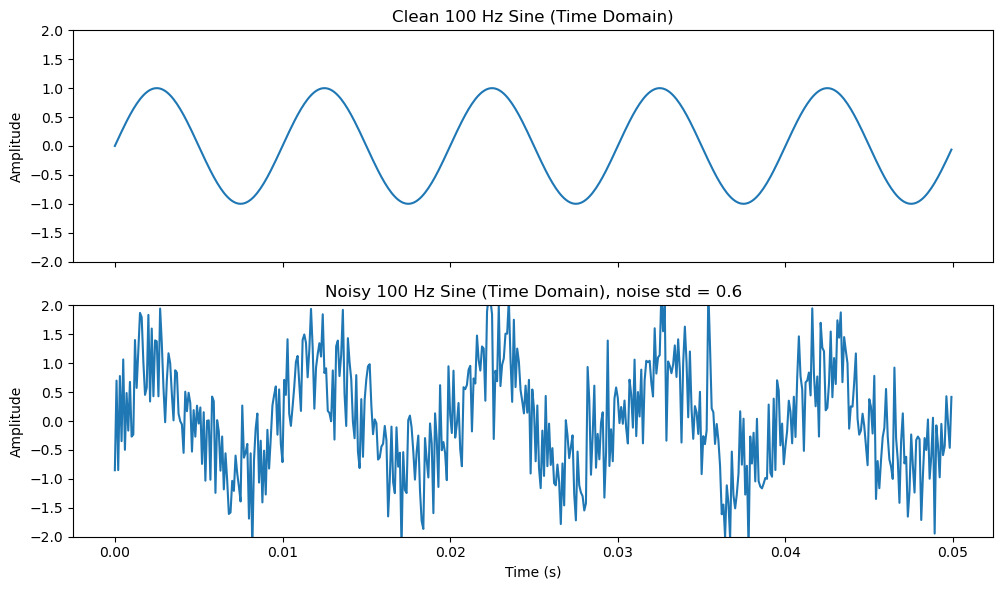

In [21]:
# Clean 100 Hz sine
A, f, phase = 1, 100, 0
x_clean = generate_sine(A, f, phase, t)

# Add noise
noise_std = 0.6  # try changing this to see what changes
n = generate_noise(noise_std, t)
x_noisy = x_clean + n

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(t, x_clean)
axes[0].set_title("Clean 100 Hz Sine (Time Domain)")
axes[0].set_ylabel("Amplitude")
axes[0].set_ylim(-2, 2)

axes[1].plot(t, x_noisy)
axes[1].set_title(f"Noisy 100 Hz Sine (Time Domain), noise std = {noise_std}")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Amplitude")
axes[1].set_ylim(-2.0, 2.0)

plt.tight_layout()
plt.show()

### Observations: 
#### - With no noise we get a clean and easy to detect wave
#### - When we add just a little bit of noise, the signal becomes much harder to detect
#### - As we increase the noise level, the wave becomes more chaotic
#### - At high noise levels the signal seems like random noise and the 100 Hz frequency is hidden underneath

## 4.2 No noise vs Noisy 100 Hz sine wave (Frequency domain)

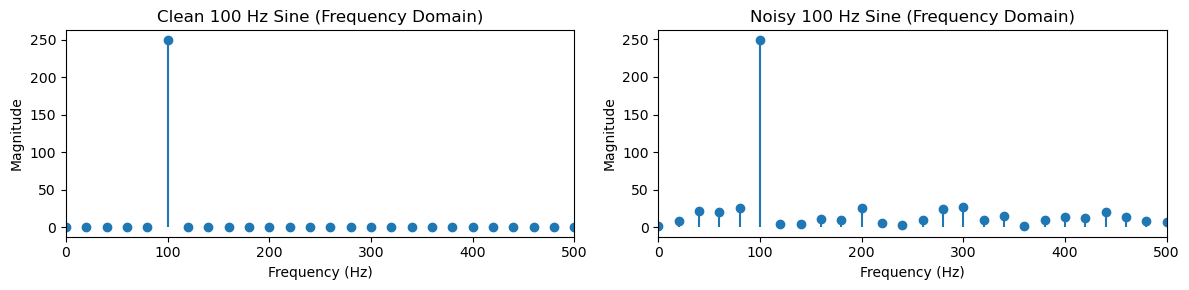

In [7]:
# Compute FFTs
freqs_clean, mag_clean = compute_fft(x_clean, fs)
freqs_noisy, mag_noisy = compute_fft(x_noisy, fs)

fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# Clean spectrum
axes[0].stem(freqs_clean, mag_clean, basefmt=" ")
axes[0].set_title("Clean 100 Hz Sine (Frequency Domain)")
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("Magnitude")
axes[0].set_xlim(0, 500)

# Noisy spectrum
axes[1].stem(freqs_noisy, mag_noisy, basefmt=" ")
axes[1].set_title("Noisy 100 Hz Sine (Frequency Domain)")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Magnitude")
axes[1].set_xlim(0, 500)

plt.tight_layout()
plt.show()

### Observations: 
#### - Without noise there is one big spike at 100 Hz
#### - When noise is added you can still see the spike at 100 Hz but also have many smaller spikes throughout the spectrum

## 4.3 Noise at different levels

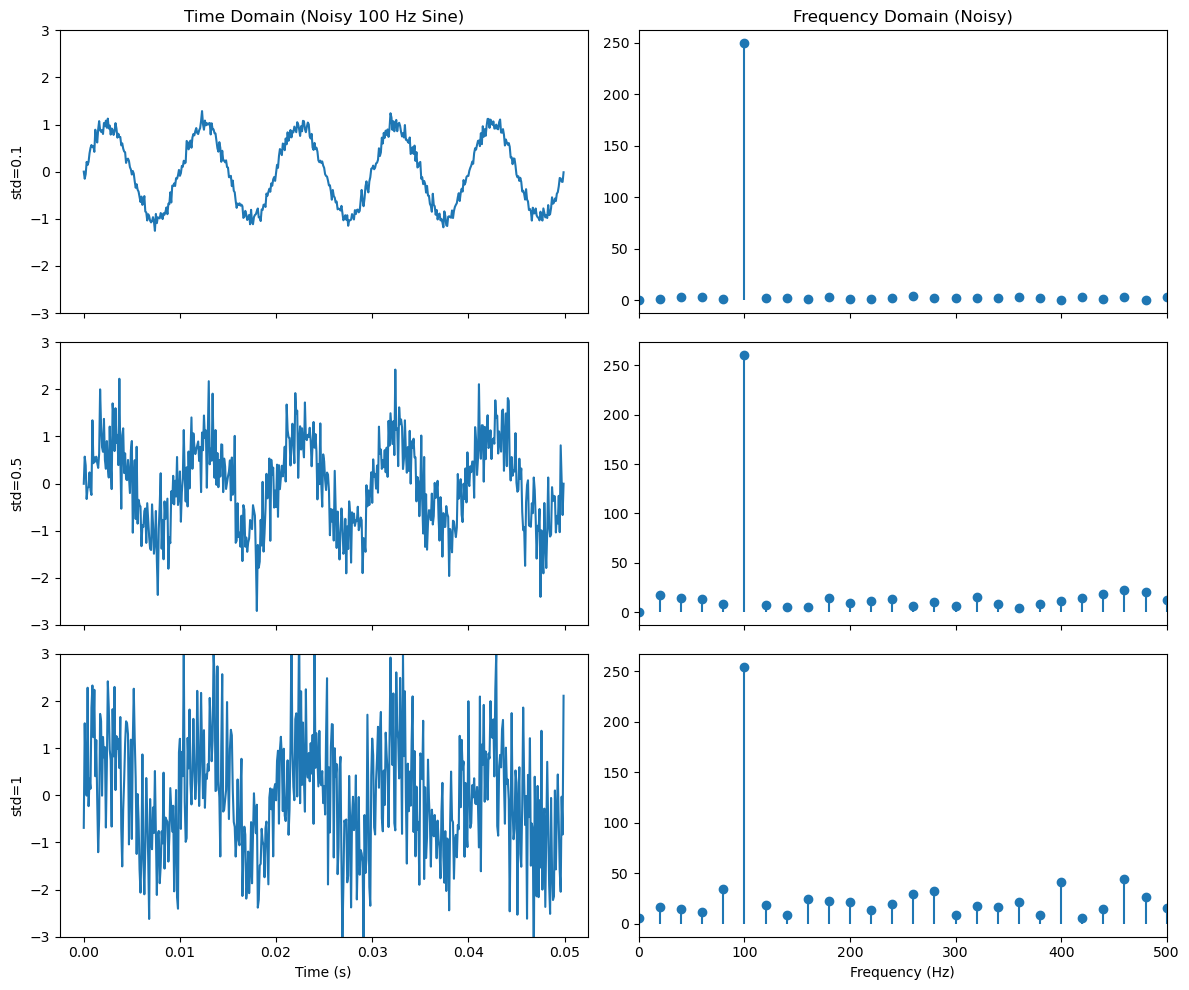

In [14]:
noise_levels = [0.1, 0.5, 1]  # standard deviations
A, f, phase = 1, 100, 0
x_clean = generate_sine(A, f, phase, t)

fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex='col')

for i, std in enumerate(noise_levels):
    n = generate_noise(std, t)
    x_noisy = x_clean + n

    freqs_noisy, mag_noisy = compute_fft(x_noisy, fs)

    # Time-domain (left column)
    axes[i, 0].plot(t, x_noisy)
    axes[0, 0].set_title("Time Domain (Noisy 100 Hz Sine)")
    axes[i, 0].set_ylabel(f"std={std}")

    # Frequency-domain (right column)
    axes[i, 1].stem(freqs_noisy, mag_noisy, basefmt=" ")
    axes[0, 1].set_title("Frequency Domain (Noisy)")

    axes[i, 1].set_xlim(0, 500)
    axes[i,0].set_ylim(-3.0, 3.0)
axes[2, 0].set_xlabel("Time (s)")
axes[2, 1].set_xlabel("Frequency (Hz)")

plt.tight_layout()
plt.show()

### Observations:
#### - As we increase noise the signal becomes harder to read and the frequencies become more chaotic
#### - As the noise level increases the height of the signal increases fairly significantly 
#### - High singal-to-noise ratio: peaks stand out clearly above the noise
#### - Low signal-to-noise ratio: peaks are hard are blurry and hard to point out

# 5. Conclusions

#### We used simple noise models to show how much even a small disturbance can change a waveform. We also saw how noise in time domain makes the waveform look like static harder to interpret by eye, especially at higher noise levels. Although the frequency domain wasn't heavily affect it still made new smaller peaks throughout the spectrum. This leads to the concept of signal-to-noise ratio (SNR) which tells us how strong the signal is compared to the surrounding noise.

# 6. Future Questions

#### How can we measure the SNR numerically?
#### What can we do to filter out the noise and make the signal clean again?
#### How do different types of noises affect it differently?